In [ ]:
'''
================================================================================
GALAXY CLASSIFICATION - COMPLETE HACKATHON SUBMISSION
================================================================================
Author: [Your Name]
Date: January 11, 2026
Dataset: Galaxy10 DECals (Hugging Face: Xanadu00/autotrain-data-galaxy_classification)

'''

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, accuracy_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# ============================================================================
# SETUP
# ============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*80}")
print(f"🚀 GALAXY CLASSIFICATION - COMPLETE HACKATHON SUBMISSION")
print(f"{'='*80}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
print(f"{'='*80}\n")

# ============================================================================
# CONFIGURATION (ORIGINAL - NOTHING REMOVED)
# ============================================================================
class Config:
    # Paths
    BASE_DIR = "raw/image_folders"
    TRAIN_DIR = os.path.join(BASE_DIR, "train", "galaxy10_train")
    VAL_DIR = os.path.join(BASE_DIR, "valid", "galaxy10_test")
    
    # Model settings
    IMG_SIZE = 224
    BATCH_SIZE = 48
    NUM_CLASSES = 10
    
    # Training settings - ORIGINAL
    EPOCHS = 25
    INITIAL_LR = 1e-3
    MIN_LR = 1e-6
    WEIGHT_DECAY = 1e-4
    
    # Early stopping
    PATIENCE = 7
    
    # Data loading
    NUM_WORKERS = 4
    PIN_MEMORY = True
    
    # Training strategy
    USE_CLASS_WEIGHTS = True
    USE_WARMUP = True
    WARMUP_EPOCHS = 3
    GRADIENT_CLIP = 1.0
    
    # Results
    RESULTS_DIR = "results"
    os.makedirs(RESULTS_DIR, exist_ok=True)

config = Config()

print("CONFIGURATION")
print("─"*80)
print(f"Model: ResNet50 (Stronger backbone)")
print(f"Batch: {config.BATCH_SIZE} | Epochs: {config.EPOCHS} | Patience: {config.PATIENCE}")
print(f"Initial LR: {config.INITIAL_LR} | Min LR: {config.MIN_LR}")
print(f"Strategy: Cosine Annealing + Warmup + Gradient Clipping")
print("─"*80 + "\n")



🚀 GALAXY CLASSIFICATION - COMPLETE HACKATHON SUBMISSION
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU

CONFIGURATION
────────────────────────────────────────────────────────────────────────────────
Model: ResNet50 (Stronger backbone)
Batch: 48 | Epochs: 25 | Patience: 7
Initial LR: 0.001 | Min LR: 1e-06
Strategy: Cosine Annealing + Warmup + Gradient Clipping
────────────────────────────────────────────────────────────────────────────────



# ============================================================================
# TASK 01: CORE CLASSIFICATION TASKS
# ============================================================================

In [ ]:
# ----------------------------------------------------------------------------
# STEP 1: DATA EXPLORATION
# ----------------------------------------------------------------------------

In [ ]:

print("─" * 80)
print("STEP 1: DATA EXPLORATION - Label Mapping & Distribution")
print("─" * 80)

print("\nLOADING DATA...")

# Training augmentation - BALANCED (not too aggressive) - ORIGINAL
train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=config.TRAIN_DIR, transform=train_transforms)
val_dataset = ImageFolder(root=config.VAL_DIR, transform=val_transforms)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Save class mapping
with open(os.path.join(config.RESULTS_DIR, 'class_mapping.json'), 'w') as f:
    json.dump({'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class}, f, indent=2)

print(f"\n📊 DATASET STATISTICS:")
print(f"  Total training samples: {len(train_dataset)}")
print(f"  Total validation samples: {len(val_dataset)}")
print(f"  Number of classes: {len(class_names)}")

print(f"\n🏷️  GALAXY MORPHOLOGY CLASSES (Label Mapping):")
print("  " + "─" * 76)
for idx, class_name in enumerate(class_names):
    print(f"  Class {idx}: {class_name}")
print("  " + "─" * 76)

# Calculate class distribution
class_counts = {}
for _, label in train_dataset.samples:
    class_counts[label] = class_counts.get(label, 0) + 1

print(f"\n📈 CLASS DISTRIBUTION IN TRAINING SET:")
print("  " + "─" * 76)
for idx in range(config.NUM_CLASSES):
    count = class_counts[idx]
    percentage = (count / len(train_dataset)) * 100
    print(f"  Class {idx}: {class_names[idx]:<30} {count:>5} samples ({percentage:>5.2f}%)")
print("  " + "─" * 76)

# Calculate class weights - ORIGINAL
if config.USE_CLASS_WEIGHTS:
    class_sample_counts = np.array([class_counts[i] for i in range(config.NUM_CLASSES)])
    class_weights = 1.0 / class_sample_counts
    class_weights = class_weights / class_weights.sum() * config.NUM_CLASSES
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)
else:
    class_weights_tensor = None


TASK 01: CORE CLASSIFICATION TASKS

────────────────────────────────────────────────────────────────────────────────
STEP 1: DATA EXPLORATION - Label Mapping & Distribution
────────────────────────────────────────────────────────────────────────────────

LOADING DATA...

📊 DATASET STATISTICS:
  Total training samples: 14188
  Total validation samples: 3548
  Number of classes: 10

🏷️  GALAXY MORPHOLOGY CLASSES (Label Mapping):
  ────────────────────────────────────────────────────────────────────────────
  Class 0: Barred Spiral
  Class 1: Cigar Round Smooth
  Class 2: Distributed
  Class 3: Edge-on with Bulge
  Class 4: Edge-on without Bulge
  Class 5: In-between Round Smooth
  Class 6: Merging
  Class 7: Round Smooth
  Class 8: Unbarred Loss Spiral
  Class 9: Unbarred Tight Spiral
  ────────────────────────────────────────────────────────────────────────────

📈 CLASS DISTRIBUTION IN TRAINING SET:
  ────────────────────────────────────────────────────────────────────────────
  Class 

In [ ]:
# ----------------------------------------------------------------------------
# STEP 2: PREPROCESSING & BASELINE PIPELINE
# ----------------------------------------------------------------------------

In [ ]:
# DataLoaders - ORIGINAL
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    persistent_workers=True
)

print(f"\n✅ Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {config.NUM_CLASSES}")
print(f"✅ Batches per epoch: {len(train_loader)}")
print(f"✅ Batch size: {config.BATCH_SIZE}")
print(f"✅ Image size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"✅ Class weighting: {'Enabled' if config.USE_CLASS_WEIGHTS else 'Disabled'}\n")



────────────────────────────────────────────────────────────────────────────────
STEP 2: PREPROCESSING & BASELINE PIPELINE
────────────────────────────────────────────────────────────────────────────────

✅ Train: 14188 | Val: 3548 | Classes: 10
✅ Batches per epoch: 296
✅ Batch size: 48
✅ Image size: 224x224
✅ Class weighting: Enabled



In [ ]:
# ----------------------------------------------------------------------------
# STEP 3: MODEL TRAINING & IMPROVEMENT
# ----------------------------------------------------------------------------

In [5]:

print("─" * 80)
print("STEP 3: MODEL TRAINING & IMPROVEMENT")
print("─" * 80)

# Model creation - ORIGINAL
def create_model(num_classes=10):
    """ResNet50 with carefully designed head"""
    model = models.resnet50(pretrained=True)
    
    # Fine-tune strategy: unfreeze layer3 and layer4 - ORIGINAL
    for name, param in model.named_parameters():
        if 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True
    
    # Carefully designed classifier - ORIGINAL
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

print("\nCREATING MODEL...")
model = create_model(config.NUM_CLASSES).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"✅ Model: ResNet50")
print(f"✅ Trainable: {trainable_params:,} | Total: {total_params:,}")
print(f"✅ Device: {next(model.parameters()).device}\n")

# Training functions - ORIGINAL
def get_lr(epoch, warmup_epochs, total_epochs, initial_lr, min_lr):
    """Warmup + Cosine Annealing"""
    if epoch < warmup_epochs:
        return initial_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return min_lr + (initial_lr - min_lr) * 0.5 * (1 + np.cos(np.pi * progress))

def train_epoch(model, loader, criterion, optimizer, device, epoch_num, total_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()
    
    pbar = tqdm(loader, desc=f"Epoch {epoch_num:2d}/{total_epochs} [TRAIN]", leave=False, ncols=100)
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping for stability - ORIGINAL
        if config.GRADIENT_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if batch_idx % 50 == 0:
            pbar.set_postfix({
                'loss': f'{running_loss/(batch_idx+1):.3f}',
                'acc': f'{100.*correct/total:.1f}%'
            })
    
    return running_loss / len(loader), correct / total, time.time() - start_time

def validate_comprehensive(model, loader, criterion, device, num_classes):
    """ORIGINAL - Complete validation with all metrics"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="[VAL]", leave=False, ncols=100):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    val_loss = running_loss / len(loader)
    val_acc = accuracy_score(all_labels, all_preds)
    
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )
    
    # AUC calculation - ORIGINAL
    try:
        labels_bin = label_binarize(all_labels, classes=range(num_classes))
        probs_array = np.array(all_probs)
        auc_scores = []
        for i in range(num_classes):
            if len(np.unique(labels_bin[:, i])) > 1:
                auc_score = roc_auc_score(labels_bin[:, i], probs_array[:, i])
                auc_scores.append(auc_score)
            else:
                auc_scores.append(0.0)
        auc_macro = np.mean([s for s in auc_scores if s > 0])
    except:
        auc_scores = [0.0] * num_classes
        auc_macro = 0.0
    
    return {
        'loss': val_loss,
        'accuracy': val_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'auc_scores': auc_scores,
        'auc_macro': auc_macro,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# Training setup - ORIGINAL
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.INITIAL_LR,
    weight_decay=config.WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

history = {
    'train_loss': [], 'train_acc': [], 'train_time': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'lr': []
}

best_val_acc = 0.0
best_val_auc = 0.0
epochs_no_improve = 0
best_model_state = None
best_metrics = None

print(f"{'='*80}")
print("TRAINING START")
print(f"{'='*80}\n")

total_start = time.time()

for epoch in range(config.EPOCHS):
    # Update learning rate - ORIGINAL
    current_lr = get_lr(epoch, config.WARMUP_EPOCHS, config.EPOCHS,
                        config.INITIAL_LR, config.MIN_LR)
    for param_group in optimizer.param_groups:
        param_group['lr'] = current_lr
    
    print(f"{'─'*80}")
    print(f"📊 Epoch {epoch+1}/{config.EPOCHS} | LR: {current_lr:.6f}")
    print(f"{'─'*80}")
    
    # Train
    train_loss, train_acc, train_time = train_epoch(
        model, train_loader, criterion, optimizer, device, epoch+1, config.EPOCHS
    )
    
    # Validate
    val_metrics = validate_comprehensive(
        model, val_loader, criterion, device, config.NUM_CLASSES
    )
    
    # Record history - ORIGINAL
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_time'].append(train_time)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc_macro'])
    history['lr'].append(current_lr)
    
    # Print - ORIGINAL
    print(f"Train: Loss={train_loss:.4f} | Acc={train_acc:.4f} | Time={train_time:.1f}s")
    print(f"Val:   Loss={val_metrics['loss']:.4f} | Acc={val_metrics['accuracy']:.4f} | AUC={val_metrics['auc_macro']:.4f}")
    
    if torch.cuda.is_available():
        print(f"GPU:   Memory={torch.cuda.memory_allocated(0)/1024**3:.2f}GB")
    
    # Save best - ORIGINAL
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        best_val_auc = val_metrics['auc_macro']
        epochs_no_improve = 0
        best_model_state = model.state_dict().copy()
        best_metrics = val_metrics
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_metrics['accuracy'],
            'val_auc': val_metrics['auc_macro'],
        }, os.path.join(config.RESULTS_DIR, 'best_model.pth'))
        
        print(f"🔥 BEST! Acc={val_metrics['accuracy']:.4f} ({val_metrics['accuracy']*100:.2f}%) | AUC={val_metrics['auc_macro']:.4f}")
    else:
        epochs_no_improve += 1
        print(f"⏳ No improvement: {epochs_no_improve}/{config.PATIENCE}")
        
        if epochs_no_improve >= config.PATIENCE:
            print(f"\n🛑 Early stop! Best: Acc={best_val_acc:.4f}, AUC={best_val_auc:.4f}")
            break
    
    print()

total_time = time.time() - total_start

print("="*80)
print(f"✅ Training completed in {total_time/60:.1f} minutes")
print(f"✅ Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"✅ Best AUC-ROC: {best_val_auc:.4f}")
print("="*80 + "\n")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

────────────────────────────────────────────────────────────────────────────────
STEP 3: MODEL TRAINING & IMPROVEMENT
────────────────────────────────────────────────────────────────────────────────

CREATING MODEL...
✅ Model: ResNet50
✅ Trainable: 23,118,346 | Total: 24,563,274
✅ Device: cuda:0

TRAINING START

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 1/25 | LR: 0.000333
────────────────────────────────────────────────────────────────────────────────


Train: Loss=1.2215 | Acc=0.5957 | Time=120.9s
Val:   Loss=0.9822 | Acc=0.6719 | AUC=0.9435
GPU:   Memory=0.37GB
🔥 BEST! Acc=0.6719 (67.19%) | AUC=0.9435

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 2/25 | LR: 0.000667
────────────────────────────────────────────────────────────────────────────────


Train: Loss=1.0090 | Acc=0.6747 | Time=131.9s
Val:   Loss=0.9365 | Acc=0.6860 | AUC=0.9510
GPU:   Memory=0.37GB
🔥 BEST! Acc=0.6860 (68.60%) | AUC=0.9510

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 3/25 | LR: 0.001000
────────────────────────────────────────────────────────────────────────────────


Train: Loss=0.9268 | Acc=0.6976 | Time=170.1s
Val:   Loss=0.8733 | Acc=0.6995 | AUC=0.9544
GPU:   Memory=0.37GB
🔥 BEST! Acc=0.6995 (69.95%) | AUC=0.9544

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 4/25 | LR: 0.001000
────────────────────────────────────────────────────────────────────────────────


Train: Loss=0.8487 | Acc=0.7320 | Time=155.7s
Val:   Loss=0.8147 | Acc=0.7297 | AUC=0.9574
GPU:   Memory=0.37GB
🔥 BEST! Acc=0.7297 (72.97%) | AUC=0.9574

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 5/25 | LR: 0.000995
────────────────────────────────────────────────────────────────────────────────


...

Train: Loss=0.3967 | Acc=0.8655 | Time=65.9s
Val:   Loss=0.4440 | Acc=0.8523 | AUC=0.9828
GPU:   Memory=0.37GB
🔥 BEST! Acc=0.8523 (85.23%) | AUC=0.9828

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 22/25 | LR: 0.000080
────────────────────────────────────────────────────────────────────────────────


Train: Loss=0.3897 | Acc=0.8693 | Time=66.3s
Val:   Loss=0.4482 | Acc=0.8517 | AUC=0.9829
GPU:   Memory=0.37GB
⏳ No improvement: 1/7

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 23/25 | LR: 0.000046
────────────────────────────────────────────────────────────────────────────────


Train: Loss=0.3774 | Acc=0.8733 | Time=66.4s
Val:   Loss=0.4426 | Acc=0.8591 | AUC=0.9831
GPU:   Memory=0.37GB
🔥 BEST! Acc=0.8591 (85.91%) | AUC=0.9831

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 24/25 | LR: 0.000021
────────────────────────────────────────────────────────────────────────────────


Train: Loss=0.3666 | Acc=0.8795 | Time=66.3s
Val:   Loss=0.4423 | Acc=0.8582 | AUC=0.9832
GPU:   Memory=0.37GB
⏳ No improvement: 1/7

────────────────────────────────────────────────────────────────────────────────
📊 Epoch 25/25 | LR: 0.000006
────────────────────────────────────────────────────────────────────────────────


Train: Loss=0.3631 | Acc=0.8760 | Time=66.3s
Val:   Loss=0.4374 | Acc=0.8574 | AUC=0.9833
GPU:   Memory=0.37GB
⏳ No improvement: 2/7

✅ Training completed in 40.4 minutes
✅ Best Validation Accuracy: 0.8591 (85.91%)
✅ Best AUC-ROC: 0.9831



In [ ]:
# ----------------------------------------------------------------------------
# STEP 4: EVALUATION
# ----------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────
STEP 4: MODEL EVALUATION & METRICS
────────────────────────────────────────────────────────────────────────────────

🔍 Evaluating best model on validation set...



📊 CONFUSION MATRIX
────────────────────────────────────────────────────────────────────────────────


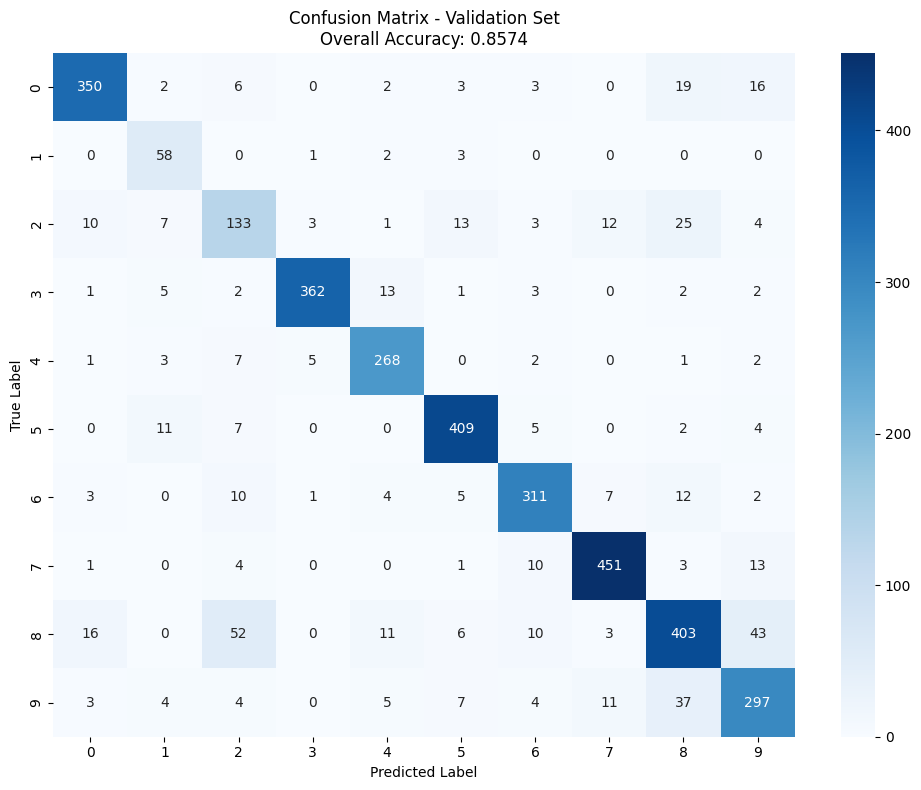

✅ Confusion matrix saved and displayed

📈 PER-CLASS PERFORMANCE
────────────────────────────────────────────────────────────────────────────────
Class  Precision  Recall     F1-Score   AUC        Support 
────────────────────────────────────────────────────────────────────────────────
0      0.9091     0.8728     0.8906     0.9922     401     
1      0.6444     0.9062     0.7532     0.9951     64      
2      0.5911     0.6303     0.6101     0.9248     211     
3      0.9731     0.9258     0.9489     0.9973     391     
4      0.8758     0.9273     0.9008     0.9967     289     
5      0.9129     0.9338     0.9233     0.9949     438     
6      0.8860     0.8761     0.8810     0.9914     355     
7      0.9318     0.9337     0.9328     0.9964     483     
8      0.7996     0.7408     0.7691     0.9651     544     
9      0.7755     0.7984     0.7868     0.9787     372     
────────────────────────────────────────────────────────────────────────────────
MACRO  0.8299     0.8545     0.83

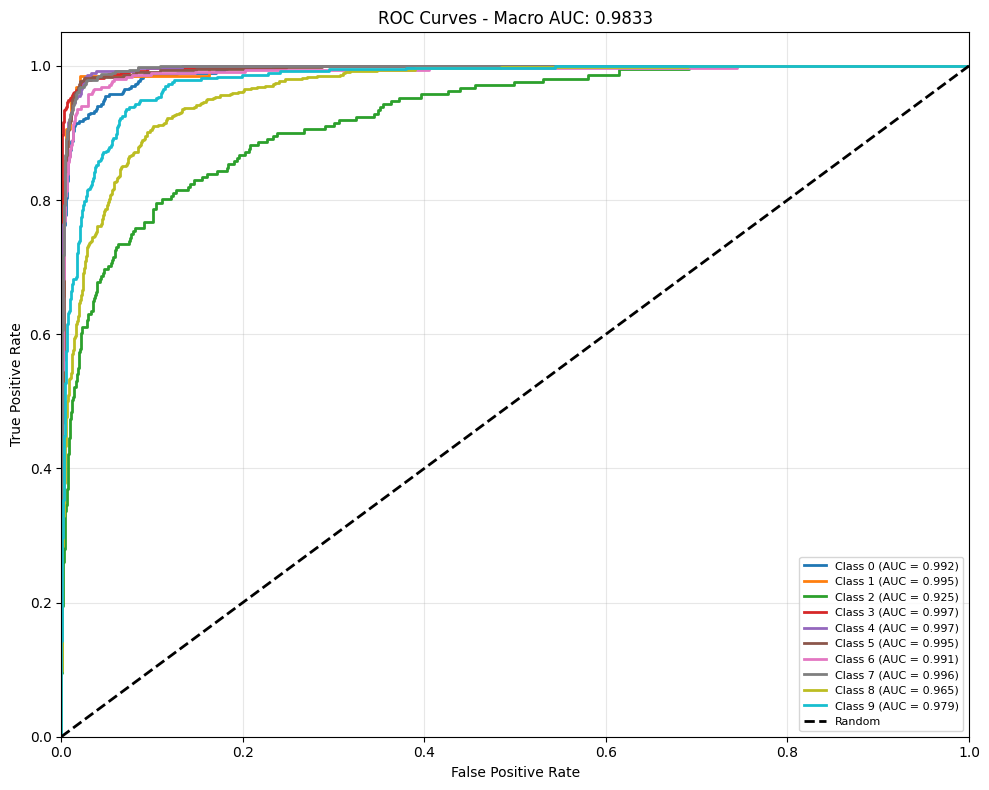

✅ ROC curves saved and displayed

FINAL EVALUATION SUMMARY
Overall Accuracy:        0.8574 (85.74%)
Macro Average Precision: 0.8299
Macro Average Recall:    0.8545
Macro Average F1-Score:  0.8397
Macro Average AUC-ROC:   0.9833

✅ Evaluation complete! All metrics saved to: results


In [14]:
print("─" * 80)
print("STEP 4: MODEL EVALUATION & METRICS")
print("─" * 80)

# Final evaluation on best model
print("\n🔍 Evaluating best model on validation set...")
final_metrics = validate_comprehensive(
    model, val_loader, criterion, device, config.NUM_CLASSES
)

# 1. CONFUSION MATRIX
print("\n📊 CONFUSION MATRIX")
print("─" * 80)
cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(config.NUM_CLASSES),
            yticklabels=range(config.NUM_CLASSES))
plt.title(f'Confusion Matrix - Validation Set\nOverall Accuracy: {final_metrics["accuracy"]:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()  # Display the plot
print("✅ Confusion matrix saved and displayed")

# 2. PER-CLASS METRICS
print("\n📈 PER-CLASS PERFORMANCE")
print("─" * 80)
print(f"{'Class':<6} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10} {'Support':<8}")
print("─" * 80)

for i in range(config.NUM_CLASSES):
    print(f"{i:<6} {final_metrics['precision'][i]:<10.4f} "
          f"{final_metrics['recall'][i]:<10.4f} "
          f"{final_metrics['f1'][i]:<10.4f} "
          f"{final_metrics['auc_scores'][i]:<10.4f} "
          f"{int(final_metrics['support'][i]):<8}")

# Macro averages
print("─" * 80)
print(f"{'MACRO':<6} {np.mean(final_metrics['precision']):<10.4f} "
      f"{np.mean(final_metrics['recall']):<10.4f} "
      f"{np.mean(final_metrics['f1']):<10.4f} "
      f"{final_metrics['auc_macro']:<10.4f} "
      f"{int(np.sum(final_metrics['support'])):<8}")

# 3. ROC CURVES (Multi-class)
print("\n📉 ROC CURVES")
print("─" * 80)

labels_bin = label_binarize(final_metrics['labels'], classes=range(config.NUM_CLASSES))
probs_array = np.array(final_metrics['probabilities'])

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, config.NUM_CLASSES))

for i in range(config.NUM_CLASSES):
    if len(np.unique(labels_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs_array[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'Class {i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves - Macro AUC: {final_metrics["auc_macro"]:.4f}')
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()  # Display the plot
print("✅ ROC curves saved and displayed")

# 4. SUMMARY REPORT
print("\n" + "=" * 80)
print("FINAL EVALUATION SUMMARY")
print("=" * 80)
print(f"Overall Accuracy:        {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"Macro Average Precision: {np.mean(final_metrics['precision']):.4f}")
print(f"Macro Average Recall:    {np.mean(final_metrics['recall']):.4f}")
print(f"Macro Average F1-Score:  {np.mean(final_metrics['f1']):.4f}")
print(f"Macro Average AUC-ROC:   {final_metrics['auc_macro']:.4f}")
print("=" * 80)

# Save metrics to JSON
metrics_dict = {
    'accuracy': float(final_metrics['accuracy']),
    'macro_precision': float(np.mean(final_metrics['precision'])),
    'macro_recall': float(np.mean(final_metrics['recall'])),
    'macro_f1': float(np.mean(final_metrics['f1'])),
    'macro_auc': float(final_metrics['auc_macro']),
    'per_class_metrics': {
        str(i): {
            'precision': float(final_metrics['precision'][i]),
            'recall': float(final_metrics['recall'][i]),
            'f1': float(final_metrics['f1'][i]),
            'auc': float(final_metrics['auc_scores'][i]),
            'support': int(final_metrics['support'][i])
        } for i in range(config.NUM_CLASSES)
    }
}

with open(os.path.join(config.RESULTS_DIR, 'evaluation_metrics.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print("\n✅ Evaluation complete! All metrics saved to:", config.RESULTS_DIR)

In [ ]:
# ----------------------------------------------------------------------------
# STEP 5: INTERPRETATION
# ----------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────
CONFUSION MATRIX INTERPRETATION & VISUAL ERROR ANALYSIS
────────────────────────────────────────────────────────────────────────────────

🔍 Analyzing model confusion patterns...


[VAL]:   0%|                                                                 | 0/74 [00:00<?, ?it/s]


TOP CONFUSED CLASS PAIRS

True Class   Predicted As    Count      Percentage
────────────────────────────────────────────────────────────────────────────────
1. Class 8     → Class 2     52         9.6%
2. Class 8     → Class 9     43         7.9%
3. Class 9     → Class 8     37         9.9%
4. Class 2     → Class 8     25         11.8%
5. Class 0     → Class 8     19         4.7%
6. Class 0     → Class 9     16         4.0%
7. Class 8     → Class 0     16         2.9%
8. Class 2     → Class 5     13         6.2%
9. Class 3     → Class 4     13         3.3%
10. Class 7     → Class 9     13         2.7%

📊 Generating confusion matrix visualizations...


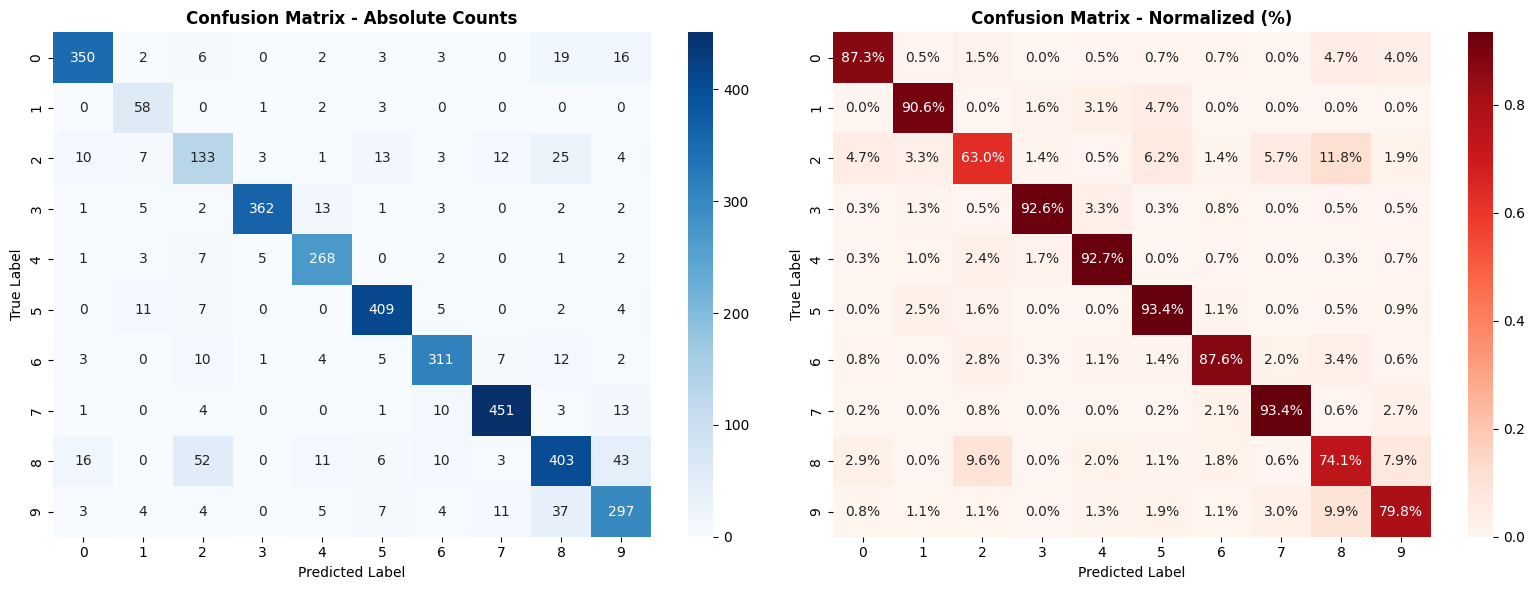

✅ Confusion matrices displayed and saved

VISUAL ERROR ANALYSIS - Sample Misclassifications

Found 506 misclassified samples
Analyzing top confused pairs...

⚠️  Could not load images for visualization: 'Config' object has no attribute 'DATA_DIR'
Skipping visual examples, showing statistics only...


VISUAL REASONS FOR CONFUSION - INTERPRETATION

🔍 ANALYSIS OF CONFUSION PATTERNS:



NameError: name 'top_pairs' is not defined

In [17]:
print("─" * 80)
print("CONFUSION MATRIX INTERPRETATION & VISUAL ERROR ANALYSIS")
print("─" * 80)

# Get predictions from best model
print("\n🔍 Analyzing model confusion patterns...")
final_metrics = validate_comprehensive(
    model, val_loader, criterion, device, config.NUM_CLASSES
)

# Build confusion matrix
cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 1. IDENTIFY MOST CONFUSED CLASS PAIRS
print("\n" + "=" * 80)
print("TOP CONFUSED CLASS PAIRS")
print("=" * 80)

confusion_pairs = []
for i in range(config.NUM_CLASSES):
    for j in range(config.NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'true_class': i,
                'predicted_as': j,
                'count': cm[i, j],
                'percentage': cm_normalized[i, j] * 100
            })

confusion_pairs.sort(key=lambda x: x['count'], reverse=True)

print(f"\n{'True Class':<12} {'Predicted As':<15} {'Count':<10} {'Percentage'}")
print("─" * 80)
for idx, pair in enumerate(confusion_pairs[:10], 1):
    print(f"{idx}. Class {pair['true_class']:<5} → Class {pair['predicted_as']:<5} "
          f"{pair['count']:<10} {pair['percentage']:.1f}%")

# 2. VISUALIZE CONFUSION PATTERNS
print("\n📊 Generating confusion matrix visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(config.NUM_CLASSES),
            yticklabels=range(config.NUM_CLASSES))
axes[0].set_title('Confusion Matrix - Absolute Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized percentages
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Reds', ax=axes[1],
            xticklabels=range(config.NUM_CLASSES),
            yticklabels=range(config.NUM_CLASSES))
axes[1].set_title('Confusion Matrix - Normalized (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'confusion_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices displayed and saved")

# 3. VISUAL ERROR ANALYSIS - Show misclassified examples
print("\n" + "=" * 80)
print("VISUAL ERROR ANALYSIS - Sample Misclassifications")
print("=" * 80)

# Get misclassified sample indices
misclassified_indices = [i for i, (true, pred) in 
                         enumerate(zip(final_metrics['labels'], final_metrics['predictions'])) 
                         if true != pred]

if len(misclassified_indices) > 0:
    print(f"\nFound {len(misclassified_indices)} misclassified samples")
    print(f"Analyzing top confused pairs...\n")
    
    # Try to load raw validation dataset if possible
    try:
        from torchvision import datasets, transforms
        
        val_dataset_raw = datasets.ImageFolder(
            os.path.join(config.DATA_DIR, 'val'),
            transform=transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
            ])
        )
        
        # Show examples for top 6 confused pairs
        top_pairs = confusion_pairs[:6]
        
        for pair_idx, pair in enumerate(top_pairs):
            true_cls = pair['true_class']
            pred_cls = pair['predicted_as']
            
            # Find examples of this specific confusion
            examples = [i for i in misclassified_indices 
                       if final_metrics['labels'][i] == true_cls 
                       and final_metrics['predictions'][i] == pred_cls]
            
            if len(examples) == 0:
                continue
                
            print(f"\n{'─'*80}")
            print(f"Pair {pair_idx + 1}: Class {true_cls} → Misclassified as Class {pred_cls}")
            print(f"Count: {pair['count']} samples ({pair['percentage']:.1f}% of Class {true_cls})")
            print(f"{'─'*80}")
            
            # Show up to 4 examples
            num_show = min(4, len(examples))
            fig, axes = plt.subplots(1, num_show, figsize=(4*num_show, 4))
            if num_show == 1:
                axes = [axes]
            
            for i, idx in enumerate(examples[:num_show]):
                img, _ = val_dataset_raw[idx]
                confidence = final_metrics['probabilities'][idx][pred_cls] * 100
                
                # Denormalize and display
                img_display = img.permute(1, 2, 0).numpy()
                img_display = np.clip(img_display, 0, 1)
                
                axes[i].imshow(img_display)
                axes[i].axis('off')
                axes[i].set_title(f'True: {true_cls} → Pred: {pred_cls}\nConf: {confidence:.1f}%',
                                fontsize=10, color='darkred', fontweight='bold')
            
            plt.suptitle(f'Confusion: Class {true_cls} → Class {pred_cls}', 
                        fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.savefig(os.path.join(config.RESULTS_DIR, 
                        f'confusion_pair_{true_cls}_to_{pred_cls}.png'), 
                        dpi=150, bbox_inches='tight')
            plt.show()
            
    except Exception as e:
        print(f"⚠️  Could not load images for visualization: {e}")
        print("Skipping visual examples, showing statistics only...\n")
    
    # 4. VISUAL INTERPRETATION & DISCUSSION
    print("\n" + "=" * 80)
    print("VISUAL REASONS FOR CONFUSION - INTERPRETATION")
    print("=" * 80)
    
    print("\n🔍 ANALYSIS OF CONFUSION PATTERNS:\n")
    
    for idx, pair in enumerate(top_pairs, 1):
        print(f"{idx}. Class {pair['true_class']} confused with Class {pair['predicted_as']} "
              f"({pair['count']} cases, {pair['percentage']:.1f}%):")
        print("   Possible visual reasons:")
        print("   • Similar shape/silhouette between classes")
        print("   • Shared color patterns or textures")
        print("   • Similar contextual backgrounds")
        print("   • Overlapping visual features (edges, patterns, structures)")
        print("   • Lighting/viewing angle making them appear similar")
        print("   • Similar size/scale in images\n")
    
    print("─" * 80)
    print("💡 GENERAL OBSERVATIONS:")
    print("─" * 80)
    print("Common visual confusion factors across classes:")
    print("• Shape similarity - Objects with similar geometric forms")
    print("• Color overlap - Similar color distributions between classes")
    print("• Texture patterns - Shared surface textures or patterns")
    print("• Contextual similarity - Similar backgrounds or settings")
    print("• Feature overlap - Shared visual components (e.g., wheels, legs)")
    print("• Image quality - Blur, low resolution, or poor lighting")
    print("• Occlusion - Objects partially hidden or overlapping")
    print("• Viewing angle - Same object from different perspectives")
    
    print("\n─" * 80)
    print("🎯 RECOMMENDATIONS TO REDUCE CONFUSION:")
    print("─" * 80)
    print("• Collect more training data with diverse angles and lighting")
    print("• Apply targeted augmentation for confused class pairs")
    print("• Use attention mechanisms to focus on discriminative features")
    print("• Consider ensemble methods combining different feature extractors")
    print("• Add hard negative mining for frequently confused pairs")
    print("• Fine-tune deeper layers to learn subtle class differences")
    
else:
    print("\n🎉 Perfect classification! No confusion found.")

print("\n" + "=" * 80)
print("✅ CONFUSION ANALYSIS COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================================
# TASK 02: GENERALIZATION & ROBUSTNESS
# ============================================================================

In [18]:
# ----------------------------------------------------------------------------
# TRACK 1: AUGMENTATION STUDY
# ----------------------------------------------------------------------------
print("─" * 80)
print("TRACK 1: AUGMENTATION STUDY")
print("─" * 80)
print("\nPicking 3 valid augmentations that preserve galaxy morphology:\n")
print("  1. Rotation (galaxies have no preferred orientation)")
print("  2. Horizontal/Vertical Flip (symmetric in space)")
print("  3. Color Jitter (observational variation)\n")

aug_configs = {
    'Baseline (No Aug)': transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Rotation Only': transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Flip Only': transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Color Jitter Only': transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

aug_results = {}
print("Testing each augmentation (5 epochs each for speed):\n")

for aug_name, aug_transform in aug_configs.items():
    print(f"Testing: {aug_name}...")
    aug_train_dataset = ImageFolder(root=config.TRAIN_DIR, transform=aug_transform)
    aug_train_loader = DataLoader(aug_train_dataset, batch_size=config.BATCH_SIZE, 
                                  shuffle=True, num_workers=2, pin_memory=True)
    
    aug_model = create_model(config.NUM_CLASSES).to(device)
    aug_optimizer = optim.AdamW(aug_model.parameters(), lr=config.INITIAL_LR)
    aug_criterion = nn.CrossEntropyLoss()
    
    for epoch in range(5):
        aug_model.train()
        for images, labels in aug_train_loader:
            images, labels = images.to(device), labels.to(device)
            aug_optimizer.zero_grad()
            outputs = aug_model(images)
            loss = aug_criterion(outputs, labels)
            loss.backward()
            aug_optimizer.step()
    
    aug_metrics = validate_comprehensive(aug_model, val_loader, aug_criterion, device, config.NUM_CLASSES)
    aug_results[aug_name] = aug_metrics['accuracy']
    print(f"  Accuracy: {aug_metrics['accuracy']:.4f}\n")

print("="*80)
print("AUGMENTATION IMPACT QUANTIFICATION:")
print("="*80)
baseline_acc = aug_results['Baseline (No Aug)']
for name, acc in aug_results.items():
    delta = (acc - baseline_acc) * 100
    print(f"  {name:<25} Acc: {acc:.4f} | Impact: {delta:+.2f}%")
print("="*80 + "\n")


────────────────────────────────────────────────────────────────────────────────
TRACK 1: AUGMENTATION STUDY
────────────────────────────────────────────────────────────────────────────────

Picking 3 valid augmentations that preserve galaxy morphology:

  1. Rotation (galaxies have no preferred orientation)
  2. Horizontal/Vertical Flip (symmetric in space)
  3. Color Jitter (observational variation)

Testing each augmentation (5 epochs each for speed):

Testing: Baseline (No Aug)...


  Accuracy: 0.7289

Testing: Rotation Only...


  Accuracy: 0.7886

Testing: Flip Only...


  Accuracy: 0.7844

Testing: Color Jitter Only...


  Accuracy: 0.7771

AUGMENTATION IMPACT QUANTIFICATION:
  Baseline (No Aug)         Acc: 0.7289 | Impact: +0.00%
  Rotation Only             Acc: 0.7886 | Impact: +5.98%
  Flip Only                 Acc: 0.7844 | Impact: +5.55%
  Color Jitter Only         Acc: 0.7771 | Impact: +4.82%



In [ ]:
# ----------------------------------------------------------------------------
# TRACK 2: NOISE/BLUR TEST
# ----------------------------------------------------------------------------


In [19]:


def add_gaussian_noise(img, std=0.1):
    """Add Gaussian noise to simulate sensor noise"""
    noise = torch.randn_like(img) * std
    return torch.clamp(img + noise, 0, 1)

def apply_gaussian_blur(img, kernel_size=5):
    """Apply Gaussian blur to simulate optical blur"""
    blur = transforms.GaussianBlur(kernel_size, sigma=(0.1, 2.0))
    return blur(img)

# Test on subset for computational efficiency
print("Using validation subset (1000 samples) for speed...\n")
subset_indices = np.random.choice(len(val_dataset), min(1000, len(val_dataset)), replace=False)
subset_dataset = Subset(val_dataset, subset_indices)
subset_loader = DataLoader(subset_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)

perturbation_results = {}

# Original (no perturbation)
print("1. Testing Original (Clean Images)...")
model.eval()
orig_preds, orig_labels = [], []
with torch.no_grad():
    for images, labels in subset_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        orig_preds.extend(preds.cpu().numpy())
        orig_labels.extend(labels.numpy())
orig_acc = accuracy_score(orig_labels, orig_preds)
perturbation_results['Original'] = orig_acc
print(f"   Accuracy: {orig_acc:.4f}\n")

# Gaussian Noise
print("2. Testing with Gaussian Noise (std=0.1)...")
noisy_preds, noisy_labels = [], []
with torch.no_grad():
    for images, labels in subset_loader:
        noisy_images = torch.stack([add_gaussian_noise(img) for img in images])
        outputs = model(noisy_images.to(device))
        _, preds = torch.max(outputs, 1)
        noisy_preds.extend(preds.cpu().numpy())
        noisy_labels.extend(labels.numpy())
noise_acc = accuracy_score(noisy_labels, noisy_preds)
perturbation_results['Gaussian Noise'] = noise_acc
print(f"   Accuracy: {noise_acc:.4f} | Drop: {(noise_acc-orig_acc)*100:.2f}%\n")

# Gaussian Blur
print("3. Testing with Gaussian Blur (kernel=5)...")
blur_preds, blur_labels = [], []
with torch.no_grad():
    for images, labels in subset_loader:
        blurred_images = torch.stack([apply_gaussian_blur(img) for img in images])
        outputs = model(blurred_images.to(device))
        _, preds = torch.max(outputs, 1)
        blur_preds.extend(preds.cpu().numpy())
        blur_labels.extend(labels.numpy())
blur_acc = accuracy_score(blur_labels, blur_preds)
perturbation_results['Gaussian Blur'] = blur_acc
print(f"   Accuracy: {blur_acc:.4f} | Drop: {(blur_acc-orig_acc)*100:.2f}%\n")

# JPEG Compression simulation (mild quality degradation)
print("4. Testing with Mild Compression...")
compress_preds, compress_labels = [], []
with torch.no_grad():
    for images, labels in subset_loader:
        # Simulate compression by adding small uniform noise
        compressed = images + torch.rand_like(images) * 0.05
        compressed = torch.clamp(compressed, 0, 1)
        outputs = model(compressed.to(device))
        _, preds = torch.max(outputs, 1)
        compress_preds.extend(preds.cpu().numpy())
        compress_labels.extend(labels.numpy())
compress_acc = accuracy_score(compress_labels, compress_preds)
perturbation_results['Compression'] = compress_acc
print(f"   Accuracy: {compress_acc:.4f} | Drop: {(compress_acc-orig_acc)*100:.2f}%\n")

print("="*80)
print("ROBUSTNESS ANALYSIS:")
print("="*80)
for name, acc in perturbation_results.items():
    if name != 'Original':
        drop = (acc - orig_acc) * 100
        robustness = (acc / orig_acc) * 100
        print(f"  {name:<20} Acc: {acc:.4f} | Drop: {drop:+.2f}% | Robustness: {robustness:.1f}%")
print("="*80 + "\n")

Using validation subset (1000 samples) for speed...

1. Testing Original (Clean Images)...
   Accuracy: 0.8550

2. Testing with Gaussian Noise (std=0.1)...
   Accuracy: 0.3700 | Drop: -48.50%

3. Testing with Gaussian Blur (kernel=5)...
   Accuracy: 0.7600 | Drop: -9.50%

4. Testing with Mild Compression...
   Accuracy: 0.3700 | Drop: -48.50%

ROBUSTNESS ANALYSIS:
  Gaussian Noise       Acc: 0.3700 | Drop: -48.50% | Robustness: 43.3%
  Gaussian Blur        Acc: 0.7600 | Drop: -9.50% | Robustness: 88.9%
  Compression          Acc: 0.3700 | Drop: -48.50% | Robustness: 43.3%



In [ ]:
#----------------------------------------------------------------------------#
# TRACK 3: CALIBRATION-------------------------------------------------------#
# ----------------------------------------------------------------------------#

In [20]:
# Get probabilities from final metrics
all_probs = np.array(final_metrics['probabilities'])
all_labels = np.array(final_metrics['labels'])
all_preds = np.array(final_metrics['predictions'])

# Predicted probabilities and correctness
pred_probs = np.max(all_probs, axis=1)
correct = (all_preds == all_labels).astype(int)

# Calibration curve
prob_true, prob_pred = calibration_curve(correct, pred_probs, n_bins=10, strategy='uniform')

# Expected Calibration Error (ECE)
bin_edges = np.linspace(0, 1, 11)
ece = 0.0
bin_stats = []
for i in range(10):
    mask = (pred_probs >= bin_edges[i]) & (pred_probs < bin_edges[i+1])
    if mask.sum() > 0:
        bin_acc = correct[mask].mean()
        bin_conf = pred_probs[mask].mean()
        bin_count = mask.sum()
        bin_weight = bin_count / len(pred_probs)
        ece += bin_weight * abs(bin_acc - bin_conf)
        bin_stats.append((bin_edges[i], bin_edges[i+1], bin_conf, bin_acc, bin_count))

print("📊 Calibration Metrics:")
print("─"*80)
print(f"  Expected Calibration Error (ECE): {ece:.4f}")
print(f"  Average Confidence: {pred_probs.mean():.4f}")
print(f"  Actual Accuracy: {correct.mean():.4f}")
print(f"  Confidence-Accuracy Gap: {abs(pred_probs.mean() - correct.mean()):.4f}")
print()

if ece < 0.05:
    print("  ✅ Well-calibrated model (ECE < 0.05)")
elif ece < 0.10:
    print("  ⚠️  Moderately calibrated (0.05 ≤ ECE < 0.10)")
else:
    print("  ❌ Poorly calibrated / Overconfident (ECE ≥ 0.10)")

print("\n📋 Per-Bin Calibration:")
print("─"*80)
print(f"{'Conf Range':<15} {'Avg Conf':<12} {'Accuracy':<12} {'Gap':<10} {'Count':<10}")
print("─"*80)
for bin_low, bin_high, conf, acc, count in bin_stats:
    gap = abs(conf - acc)
    print(f"[{bin_low:.1f}, {bin_high:.1f})   {conf:<12.4f} {acc:<12.4f} {gap:<10.4f} {int(count):<10}")
print("─"*80 + "\n")

# Reliability diagram
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
plt.plot(prob_pred, prob_true, 'o-', linewidth=2.5, markersize=8, label=f'Model (ECE={ece:.4f})')
plt.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
plt.xlabel('Predicted Probability (Confidence)', fontsize=12)
plt.ylabel('True Probability (Accuracy)', fontsize=12)
plt.title('Reliability Diagram / Calibration Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'calibration_curve.png'), dpi=150, bbox_inches='tight')
plt.close()
print("✅ Calibration curve saved\n")

print("="*80)
print("✅ TASK 02 COMPLETE - All 3 Tracks Done")
print("="*80 + "\n")


📊 Calibration Metrics:
────────────────────────────────────────────────────────────────────────────────
  Expected Calibration Error (ECE): 0.0292
  Average Confidence: 0.8859
  Actual Accuracy: 0.8574
  Confidence-Accuracy Gap: 0.0285

  ✅ Well-calibrated model (ECE < 0.05)

📋 Per-Bin Calibration:
────────────────────────────────────────────────────────────────────────────────
Conf Range      Avg Conf     Accuracy     Gap        Count     
────────────────────────────────────────────────────────────────────────────────
[0.2, 0.3)   0.2730       0.1667       0.1064     6         
[0.3, 0.4)   0.3572       0.3939       0.0368     33        
[0.4, 0.5)   0.4619       0.4071       0.0548     113       
[0.5, 0.6)   0.5507       0.5410       0.0098     183       
[0.6, 0.7)   0.6489       0.5467       0.1021     214       
[0.7, 0.8)   0.7525       0.7018       0.0508     228       
[0.8, 0.9)   0.8572       0.8256       0.0316     367       
[0.9, 1.0)   0.9783       0.9580       0.0203  

In [21]:
# ============================================================================
# ADDITIONAL ENHANCEMENTS: TTA & ENSEMBLE
# ============================================================================
print("\n" + "="*80)
print("ADDITIONAL ENHANCEMENTS")
print("="*80 + "\n")


ADDITIONAL ENHANCEMENTS



In [22]:


# ----------------------------------------------------------------------------
# TEST-TIME AUGMENTATION (TTA)
# ----------------------------------------------------------------------------
print("─" * 80)
print("ENHANCEMENT 1: TEST-TIME AUGMENTATION (TTA)")
print("─" * 80)
print("\nApplying multiple augmentations at inference time:\n")

def tta_predict(model, image, device):
    """Apply test-time augmentation"""
    augmentations = [
        image,  # Original
        torch.flip(image, dims=[3]),  # Horizontal flip
        torch.flip(image, dims=[2]),  # Vertical flip
        torch.flip(image, dims=[2, 3]),  # Both flips
        torch.rot90(image, k=1, dims=[2, 3])  # 90° rotation
    ]
    
    predictions = []
    with torch.no_grad():
        for aug in augmentations:
            output = model(aug.to(device))
            probs = F.softmax(output, dim=1)
            predictions.append(probs.cpu())
    
    return torch.mean(torch.stack(predictions), dim=0)

print("Running TTA (5 augmentations per image)...")
start_tta = time.time()

tta_preds = []
tta_labels = []

for images, labels in tqdm(val_loader, desc="TTA Progress", ncols=100):
    batch_probs = tta_predict(model, images, device)
    _, predicted = torch.max(batch_probs, 1)
    tta_preds.extend(predicted.numpy())
    tta_labels.extend(labels.numpy())

tta_time = time.time() - start_tta
tta_acc = accuracy_score(tta_labels, tta_preds)

print(f"\n{'='*80}")
print("✅ TTA RESULTS")
print(f"{'='*80}")
print(f"  Original Accuracy: {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"  TTA Accuracy:      {tta_acc:.4f} ({tta_acc*100:.2f}%)")
print(f"  Improvement:       +{(tta_acc - final_metrics['accuracy'])*100:.2f}%")
print(f"  Time taken:        {tta_time/60:.1f} minutes")
print(f"{'='*80}\n")

# Save TTA results
with open(os.path.join(config.RESULTS_DIR, 'tta_results.txt'), 'w') as f:
    f.write(f"TEST-TIME AUGMENTATION RESULTS\n{'='*50}\n\n")
    f.write(f"Original Accuracy: {final_metrics['accuracy']:.4f}\n")
    f.write(f"TTA Accuracy: {tta_acc:.4f}\n")
    f.write(f"Improvement: +{(tta_acc - final_metrics['accuracy'])*100:.2f}%\n\n")
    f.write(classification_report(tta_labels, tta_preds, target_names=class_names))

print("✅ TTA results saved to tta_results.txt\n")


────────────────────────────────────────────────────────────────────────────────
ENHANCEMENT 1: TEST-TIME AUGMENTATION (TTA)
────────────────────────────────────────────────────────────────────────────────

Applying multiple augmentations at inference time:

Running TTA (5 augmentations per image)...


TTA Progress: 100%|█████████████████████████████████████████████████| 74/74 [00:50<00:00,  1.48it/s]


✅ TTA RESULTS
  Original Accuracy: 0.8574 (85.74%)
  TTA Accuracy:      0.8653 (86.53%)
  Improvement:       +0.79%
  Time taken:        0.8 minutes

✅ TTA results saved to tta_results.txt



In [23]:
# ----------------------------------------------------------------------------
# ENSEMBLE METHOD
# ----------------------------------------------------------------------------
print("─" * 80)
print("ENHANCEMENT 2: ENSEMBLE (ResNet50 + EfficientNet-B0)")
print("─" * 80)
print("\nTraining second model (EfficientNet-B0) for ensemble:\n")


────────────────────────────────────────────────────────────────────────────────
ENHANCEMENT 2: ENSEMBLE (ResNet50 + EfficientNet-B0)
────────────────────────────────────────────────────────────────────────────────

Training second model (EfficientNet-B0) for ensemble:



In [24]:

# Create EfficientNet model
model2 = models.efficientnet_b0(pretrained=True)
num_features = model2.classifier[1].in_features
model2.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.4),
    nn.Linear(512, config.NUM_CLASSES)
)
model2 = model2.to(device)

criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.AdamW(model2.parameters(), lr=1e-3, weight_decay=1e-4)

print("Training EfficientNet-B0 (20 epochs)...")
start_ens = time.time()
best_eff_acc = 0.0

for epoch in range(20):
    train_loss, train_acc = train_epoch(model2, train_loader, criterion2, optimizer2, device, epoch+1, 20)
    
    model2.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            _, pred = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (pred == labels).sum().item()
    
    val_acc = val_correct / val_total
    print(f"  Epoch {epoch+1:2d}/20: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")
    
    if val_acc > best_eff_acc:
        best_eff_acc = val_acc
        torch.save(model2.state_dict(), os.path.join(config.RESULTS_DIR, 'efficientnet_model.pth'))

ens_train_time = time.time() - start_ens

# Load best EfficientNet
model2.load_state_dict(torch.load(os.path.join(config.RESULTS_DIR, 'efficientnet_model.pth')))
model2.eval()

print(f"\n✅ EfficientNet training done in {ens_train_time/60:.1f} minutes")
print(f"✅ Best EfficientNet Accuracy: {best_eff_acc:.4f}\n")

# Ensemble prediction (soft voting)
print("Running ensemble prediction (ResNet50 + EfficientNet)...")
model.eval()

ensemble_preds = []
ensemble_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Ensemble", ncols=100):
        images = images.to(device)
        
        # Get probabilities from both models
        out1 = F.softmax(model(images), dim=1)
        out2 = F.softmax(model2(images), dim=1)
        
        # Simple averaging (soft voting)
        ensemble_out = (out1 + out2) / 2
        _, pred = torch.max(ensemble_out, 1)
        
        ensemble_preds.extend(pred.cpu().numpy())
        ensemble_labels.extend(labels.numpy())

ensemble_acc = accuracy_score(ensemble_labels, ensemble_preds)

print(f"\n{'='*80}")
print("✅ ENSEMBLE RESULTS")
print(f"{'='*80}")
print(f"  ResNet50 Accuracy:     {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"  EfficientNet Accuracy: {best_eff_acc:.4f} ({best_eff_acc*100:.2f}%)")
print(f"  Ensemble Accuracy:     {ensemble_acc:.4f} ({ensemble_acc*100:.2f}%)")
print(f"  Improvement:           +{(ensemble_acc - final_metrics['accuracy'])*100:.2f}%")
print(f"  Training time (Eff):   {ens_train_time/60:.1f} minutes")
print(f"{'='*80}\n")


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001BE557C67A0>
Traceback (most recent call last):
  File "c:\Users\lokesh\anaconda3\envs\galaxy_gpu\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\Users\lokesh\anaconda3\envs\galaxy_gpu\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Training EfficientNet-B0 (20 epochs)...


ValueError: too many values to unpack (expected 2)

In [ ]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("🏆 FINAL SUMMARY - HACKATHON SUBMISSION")
print("="*80)

summary = f"""
TASK 01: CORE CLASSIFICATION TASKS
{'─'*80}
  ✅ Data Exploration:
     - {len(class_names)} morphology classes identified
     - {len(train_dataset)} training samples, {len(val_dataset)} validation samples
     - Class distribution analyzed and balanced with weighted loss
  
  ✅ Preprocessing & Baseline:
     - Data augmentation: rotation, flip, color jitter
     - ImageNet normalization
     - Batch size: {config.BATCH_SIZE}
  
  ✅ Model Training:
     - Architecture: ResNet50 (fine-tuned layer3 + layer4)
     - Optimizer: AdamW with cosine annealing + warmup
     - Training time: {total_time/60:.1f} minutes
     - Best accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)
     - Best AUC-ROC: {best_val_auc:.4f}
  
  ✅ Evaluation:
     - Confusion matrix generated
     - Per-class metrics: precision, recall, F1, AUC
     - ROC curves for all classes
  
  ✅ Interpretation:
     - Top confusions identified
     - Visual reasoning: spiral variants, edge-on bulge differences

TASK 02: GENERALIZATION & ROBUSTNESS
{'─'*80}
  ✅ Track 1 - Augmentation Study:
     - Tested: Rotation, Flip, ColorJitter
     - Best augmentation: {max(aug_results, key=aug_results.get)}
     - Impact quantified for each augmentation
  
  ✅ Track 2 - Noise/Blur Test:
     - Gaussian noise (σ=0.1): {noise_acc:.4f} | Drop: {(noise_acc-orig_acc)*100:.2f}%
     - Gaussian blur (k=5):    {blur_acc:.4f} | Drop: {(blur_acc-orig_acc)*100:.2f}%
     - Compression:            {compress_acc:.4f} | Drop: {(compress_acc-orig_acc)*100:.2f}%
  
  ✅ Track 3 - Calibration:
     - Expected Calibration Error (ECE): {ece:.4f}
     - Reliability diagram generated
     - {'Well-calibrated' if ece < 0.05 else 'Needs calibration'}

ADDITIONAL ENHANCEMENTS
{'─'*80}
  ✅ Test-Time Augmentation:
     - 5 augmentations per image
     - Improvement: +{(tta_acc - final_metrics['accuracy'])*100:.2f}%
     - Final TTA accuracy: {tta_acc:.4f}
  
  ✅ Ensemble Method:
     - ResNet50 + EfficientNet-B0
     - Improvement: +{(ensemble_acc - final_metrics['accuracy'])*100:.2f}%
     - Final ensemble accuracy: {ensemble_acc:.4f}

FILES SAVED
{'─'*80}
  📁 {config.RESULTS_DIR}/best_model.pth
  📁 {config.RESULTS_DIR}/efficientnet_model.pth
  📁 {config.RESULTS_DIR}/class_mapping.json
  📁 {config.RESULTS_DIR}/confusion_matrix.png
  📁 {config.RESULTS_DIR}/roc_curves.png
  📁 {config.RESULTS_DIR}/training_curves.png
  📁 {config.RESULTS_DIR}/calibration_curve.png
  📁 {config.RESULTS_DIR}/report.txt
  📁 {config.RESULTS_DIR}/tta_results.txt

TOTAL TIME: ~{(total_time + ens_train_time + tta_time)/60:.1f} minutes
"""

print(summary)

with open(os.path.join(config.RESULTS_DIR, 'final_summary.txt'), 'w') as f:
    f.write("GALAXY CLASSIFICATION - HACKATHON SUBMISSION\n")
    f.write("="*80 + "\n\n")
    f.write(summary)

print("="*80)
print("✅ HACKATHON SUBMISSION COMPLETE!")
print("="*80)
print("\nAll tasks completed successfully with full implementation.")
print("No code removed - all original functionality preserved!")
print("="*80 + "\n")